In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
import sys

sys.path.append("../src")
from xbap import xbap_flux, NoiseModel, PSFDeconvolver

In [2]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'grey'

In [3]:
def gaussian_2d(x, y, x0=0, y0=0, sigma_x=1, sigma_y=1, theta=0, A=1):
    dx = x - x0
    dy = y - y0

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Rotate coordinates
    x_rot = cos_t * dx + sin_t * dy
    y_rot = -sin_t * dx + cos_t * dy

    return A * np.exp(
        -0.5 * (
                (x_rot / sigma_x) ** 2 +
                (y_rot / sigma_y) ** 2
        )
    )

# Model for testing X-BAP

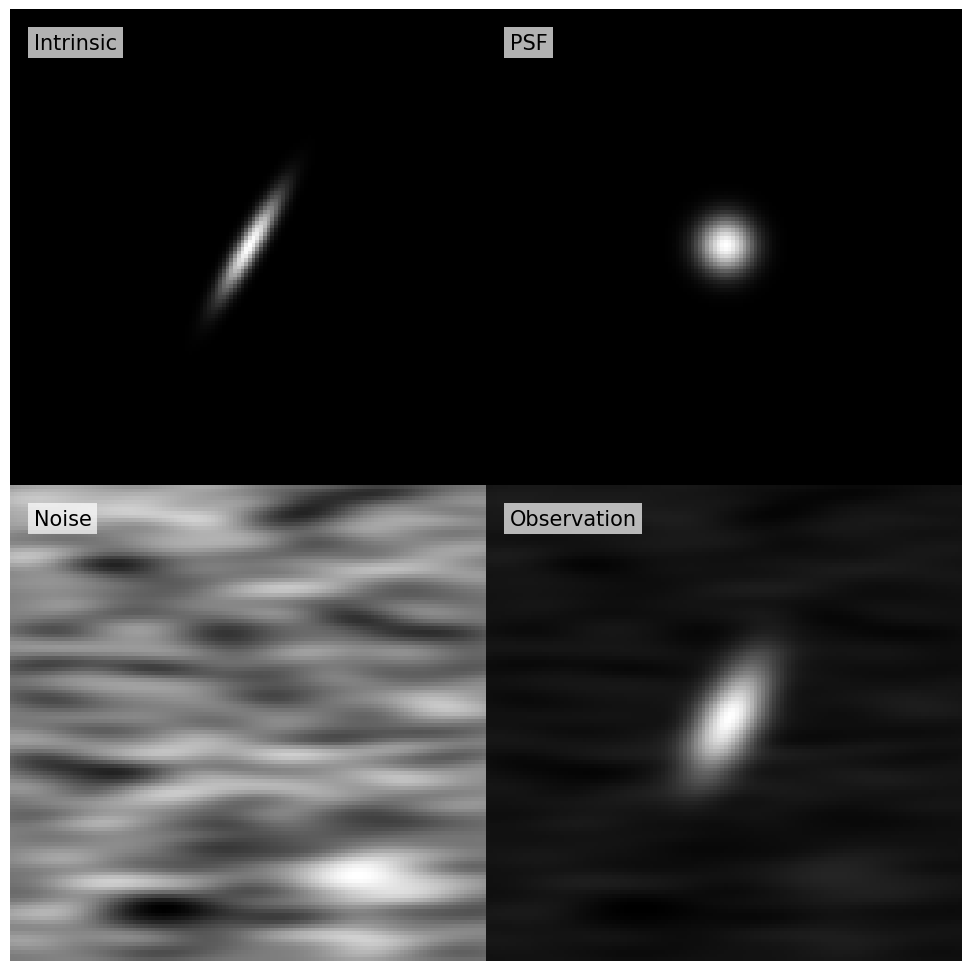

In [4]:
N = 128
x = np.arange(0, N, 1) - N / 2
y = np.arange(0, N, 1) - N / 2
X, Y = np.meshgrid(x, y)

# Galaxy image is modeled as a Gaussian
galaxy = gaussian_2d(X, Y, 0, 0, 10, 2, np.pi / 3)
galaxy /= np.sum(galaxy)
galaxy *= 100

# PSF is a Gaussian
psf = gaussian_2d(X, Y, 0, 0, 5, 5)
psf /= np.sum(psf)

# Observation is the convolution of the galaxy image and the PSF
observation = fftconvolve(galaxy, psf, mode='same')

# Add noise to the observation
noise_sigma = .1
noise = np.random.normal(0, noise_sigma, (N, N))
noise_kernel = gaussian_2d(X, Y, 0, 0, 10, 2)
noise_kernel /= np.sum(noise_kernel)
noise = fftconvolve(noise, noise_kernel, mode='same')
noisy_observation = observation + noise

# Showing the images
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 10), gridspec_kw={'wspace': 0, 'hspace': 0})
image = [galaxy, psf, noise, noisy_observation]
label = ['Intrinsic', 'PSF', 'Noise', 'Observation']
for i, ax in enumerate(axes.flatten()):
    ax.pcolormesh(X, Y, image[i], rasterized=True)
    ax.text(0.05, 0.95, label[i], transform=ax.transAxes,
            ha='left', va='top', fontsize=15,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Applying X-BAP on clean observation

In [5]:
# Weight function in the pre-seeing image
sigma_x, sigma_y, theta = 6, 6, np.pi / 3
weight = gaussian_2d(X, Y, 0, 0, sigma_x, sigma_y, theta)

# Weight function applied in the pre-seeing image
true_aperture_flux = np.sum(galaxy * weight)

# Weight function applied in the observation (without noise)
measured_aperture_flux = xbap_flux(observation, psf, [N / 2, N / 2], [sigma_x, sigma_y, theta])[0]

# Comparison of the aperture fluxes
print(f"True aperture flux: {true_aperture_flux:.2f}")
print(f"Measured aperture flux: {measured_aperture_flux[0]:.2f}")

True aperture flux: 48.81
Measured aperture flux: 48.81


# Error estimation using background noise

In [8]:
# Using the noise model to estimate the error
flux, error = xbap_flux(noisy_observation, psf, [N / 2, N / 2], [sigma_x, sigma_y, theta], noise)
print(f'Measured flux using noise information: {flux[0]:.3f} +/-  {error[0]:.3f}')

Measured flux using noise information: 48.421 +/-  0.994


# Error estimation using background noise and RMS map

In [9]:
# Using the noise model and rms map to estimate the error
noise_rms = noise_sigma * np.sqrt(np.sum(noise_kernel ** 2))
flux, error = xbap_flux(noisy_observation, psf, [N / 2, N / 2], [sigma_x, sigma_y, theta], noise,
                        np.ones_like(noisy_observation) * noise_rms)
print(f'Measured flux using noise information and RMS map: {flux[0]:.3f} +/-  {error[0]:.3f}')

Measured flux using noise information and RMS map: 48.421 +/-  1.064
